In [48]:
import pandas as pd 
import numpy as np
import yfinance as yf
import seaborn as sns


In [49]:
df= yf.download("RELIANCE.NS",start="2015-01-01", end="2024-12-31")
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.999802,190.877155,189.090351,189.657431,2963643
2015-01-02,189.496964,191.743844,189.229486,190.042631,7331366
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941
2015-01-06,178.915222,186.811376,178.037869,186.169417,18627980
2015-01-07,182.809830,183.772776,179.107845,179.129243,20720312


**FEATURE ENGINEERING:**

In [50]:
# Daily Returns
df['Return'] = df['Close'].pct_change()

# Moving Averages
df['SMA_10'] = df['Close'].rolling(10).mean()
df['SMA_50'] = df['Close'].rolling(50).mean()

# Volatility (Rolling Std)
df['Volatility'] = df['Return'].rolling(10).std()

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

**TARGET VARIABLE:**

In [58]:
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)
df.dropna(inplace=True)


In [59]:
print(X_train.isnull().sum().sum())
print(np.isinf(X_train).sum().sum())

83
0


In [60]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

**EXPLORATORY DATA ANALYSIS**

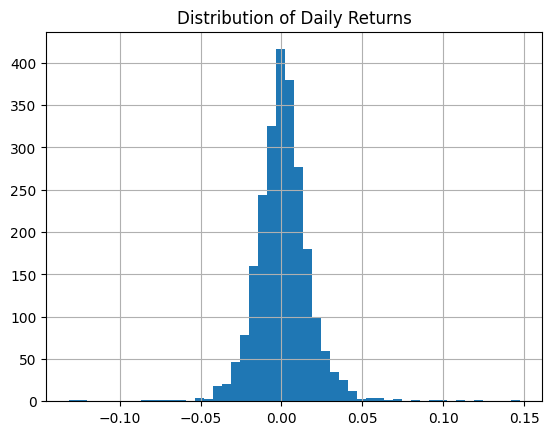

In [61]:
import matplotlib.pyplot as plt

df['Return'].hist(bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

**CORRELATION MATRIX:**

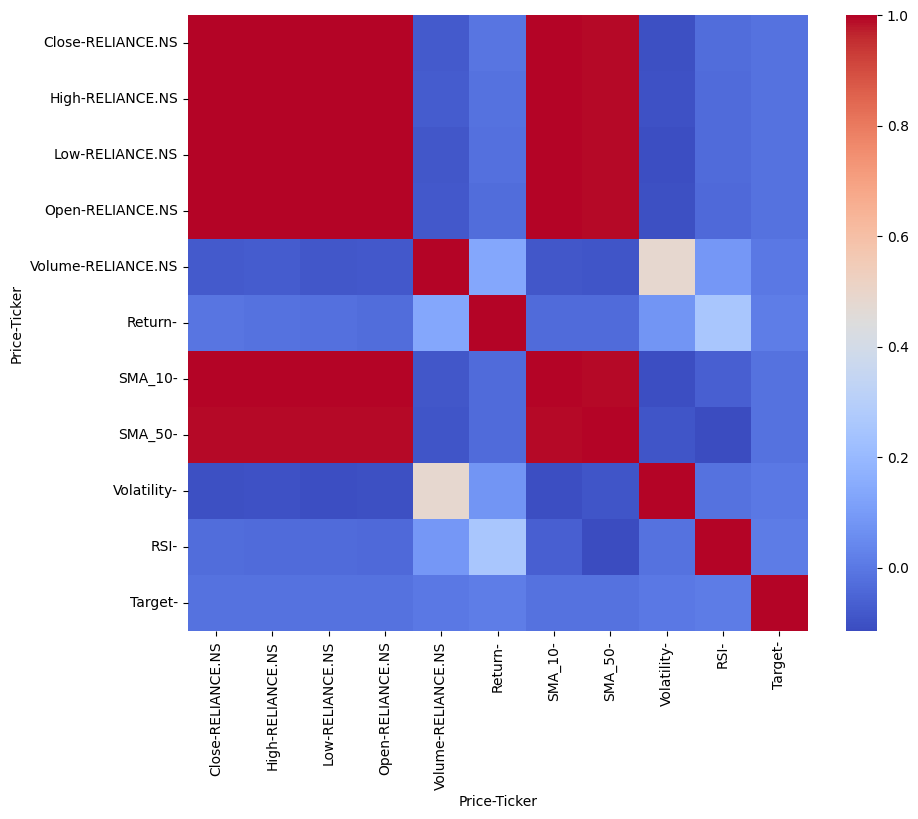

In [62]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.show()

**MODEL TRAINING & SELECTION:**



In [63]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

X_train = train.drop('Target', axis=1)
y_train = train['Target']

X_test = test.drop('Target', axis=1)
y_test = test['Target']

**LOGISTIC REGRESSION**

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

LR Accuracy: 0.506198347107438


**RANDOM FOREST**

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

RF Accuracy: 0.5020661157024794


**SUPPORT VECTOR MACHINE**

In [66]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.5103305785123967


In [67]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[180  58]
 [183  63]]
              precision    recall  f1-score   support

           0       0.50      0.76      0.60       238
           1       0.52      0.26      0.34       246

    accuracy                           0.50       484
   macro avg       0.51      0.51      0.47       484
weighted avg       0.51      0.50      0.47       484



**Backtesting Strategy**

**Simple trading rule:**

**If prediction = 1 → Buy**

**If prediction = 0 → Stay in cash**

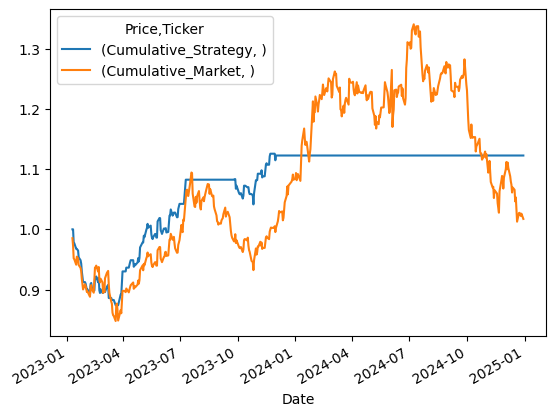

In [68]:
test['Strategy_Return'] = y_pred_rf * test['Return']
test['Cumulative_Strategy'] = (1 + test['Strategy_Return']).cumprod()
test['Cumulative_Market'] = (1 + test['Return']).cumprod()

test[['Cumulative_Strategy', 'Cumulative_Market']].plot()
plt.show()